In [1]:
# region Description of the region
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from sklearn.model_selection import train_test_split
import time
from time import sleep
from datetime import datetime
import numpy as np
from timm.utils import ModelEma
from nnunetv2.training.lr_scheduler.LinearWarmupCosine import LinearWarmupCosineAnnealingLR

from torch.cuda.amp import GradScaler, autocast
import sys
from nnunetv2.training.dataloading.data_loader_3d import nnUNetDataLoader3D
from nnunetv2.training.dataloading.nnunet_dataset import nnUNetDataset
from nnunetv2.training.data_augmentation.compute_initial_patch_size import get_patch_size
from batchgenerators.utilities.file_and_folder_operations import join, load_json, maybe_mkdir_p
from nnunetv2.utilities.plans_handling.plans_handler import PlansManager, ConfigurationManager
from nnunetv2.training.data_augmentation.custom_transforms.limited_length_multithreaded_augmenter import \
    LimitedLenWrapper
from batchgenerators.transforms.abstract_transforms import AbstractTransform, Compose
from batchgenerators.transforms.color_transforms import BrightnessMultiplicativeTransform, \
    ContrastAugmentationTransform, GammaTransform
from batchgenerators.transforms.noise_transforms import GaussianNoiseTransform, GaussianBlurTransform
from batchgenerators.transforms.resample_transforms import SimulateLowResolutionTransform
from batchgenerators.transforms.spatial_transforms import SpatialTransform, MirrorTransform
from batchgenerators.transforms.utility_transforms import RemoveLabelTransform, RenameTransform, NumpyToTensor
from nnunetv2.training.logging.nnunet_logger import nnUNetLogger
from nnunetv2.training.data_augmentation.custom_transforms.cascade_transforms import MoveSegAsOneHotToData, \
    ApplyRandomBinaryOperatorTransform, RemoveRandomConnectedComponentFromOneHotEncodingTransform
from nnunetv2.training.data_augmentation.custom_transforms.deep_supervision_donwsampling import \
    DownsampleSegForDSTransform2
from nnunetv2.training.data_augmentation.custom_transforms.masking import MaskTransform
from nnunetv2.training.data_augmentation.custom_transforms.region_based_training import \
    ConvertSegmentationToRegionsTransform
from nnunetv2.training.data_augmentation.custom_transforms.transforms_for_dummy_2d import Convert2DTo3DTransform, \
    Convert3DTo2DTransform
from nnunetv2.utilities.default_n_proc_DA import get_allowed_n_proc_DA

from typing import Union, Tuple, List

import math
from functools import partial
# from torch.utils.data import DataLoader, TensorDataset


/home/yoonji/anaconda3/envs/medmask/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data transform

def get_training_transforms(patch_size: Union[np.ndarray, Tuple[int]],
                            rotation_for_DA: dict,
                            deep_supervision_scales: Union[List, Tuple],
                            mirror_axes: Tuple[int, ...],
                            do_dummy_2d_data_aug: bool,
                            order_resampling_data: int = 3,
                            order_resampling_seg: int = 1,
                            border_val_seg: int = -1,
                            use_mask_for_norm: List[bool] = None,
                            is_cascaded: bool = False,
                            foreground_labels: Union[Tuple[int, ...], List[int]] = None,
                            regions: List[Union[List[int], Tuple[int, ...], int]] = None,
                            ignore_label: int = None) -> AbstractTransform:
    tr_transforms = []
    if do_dummy_2d_data_aug:
        ignore_axes = (0,)
        tr_transforms.append(Convert3DTo2DTransform())
        patch_size_spatial = patch_size[1:]
    else:
        patch_size_spatial = patch_size
        ignore_axes = None

    # First augmentation transform, dont change
    tr_transforms.append(SpatialTransform(
        patch_size_spatial, patch_center_dist_from_border=None,
        do_elastic_deform=False, alpha=(0, 0), sigma=(0, 0),
        do_rotation=True, angle_x=rotation_for_DA['x'], angle_y=rotation_for_DA['y'], angle_z=rotation_for_DA['z'],
        p_rot_per_axis=1,  # todo experiment with this
        do_scale=True, scale=(0.7, 1.4),
        border_mode_data="constant", border_cval_data=0, order_data=order_resampling_data,
        border_mode_seg="constant", border_cval_seg=border_val_seg, order_seg=order_resampling_seg,
        random_crop=False,  # random cropping is part of our dataloaders
        p_el_per_sample=0, p_scale_per_sample=0.2, p_rot_per_sample=0.2,
        independent_scale_for_each_axis=False  # todo experiment with this
    ))

    if do_dummy_2d_data_aug:
        tr_transforms.append(Convert2DTo3DTransform())


    # CHANGE HERE!!!!!!

    # tr_transforms.append(GaussianNoiseTransform(p_per_sample=0.1))
    # tr_transforms.append(GaussianBlurTransform((0.5, 1.), different_sigma_per_channel=True, p_per_sample=0.2,
    #                                            p_per_channel=0.5))
    # tr_transforms.append(BrightnessMultiplicativeTransform(multiplier_range=(0.75, 1.25), p_per_sample=0.15))
    # tr_transforms.append(ContrastAugmentationTransform(p_per_sample=0.15))
    # tr_transforms.append(SimulateLowResolutionTransform(zoom_range=(0.5, 1), per_channel=True,
    #                                                     p_per_channel=0.5,
    #                                                     order_downsample=0, order_upsample=3, p_per_sample=0.25,
    #                                                     ignore_axes=ignore_axes))
    # tr_transforms.append(GammaTransform((0.7, 1.5), True, True, retain_stats=True, p_per_sample=0.1))
    # tr_transforms.append(GammaTransform((0.7, 1.5), False, True, retain_stats=True, p_per_sample=0.3))

    if mirror_axes is not None and len(mirror_axes) > 0:
        tr_transforms.append(MirrorTransform(mirror_axes))

    if use_mask_for_norm is not None and any(use_mask_for_norm):
        tr_transforms.append(MaskTransform([i for i in range(len(use_mask_for_norm)) if use_mask_for_norm[i]],
                                           mask_idx_in_seg=0, set_outside_to=0))

    tr_transforms.append(RemoveLabelTransform(-1, 0))

    if is_cascaded:
        assert foreground_labels is not None, 'We need foreground_labels for cascade augmentations'
        tr_transforms.append(MoveSegAsOneHotToData(1, foreground_labels, 'seg', 'data'))
        tr_transforms.append(ApplyRandomBinaryOperatorTransform(
            channel_idx=list(range(-len(foreground_labels), 0)),
            p_per_sample=0.4,
            key="data",
            strel_size=(1, 8),
            p_per_label=1))
        tr_transforms.append(
            RemoveRandomConnectedComponentFromOneHotEncodingTransform(
                channel_idx=list(range(-len(foreground_labels), 0)),
                key="data",
                p_per_sample=0.2,
                fill_with_other_class_p=0,
                dont_do_if_covers_more_than_x_percent=0.15))

    tr_transforms.append(RenameTransform('seg', 'target', True))

    if regions is not None:
        # the ignore label must also be converted
        tr_transforms.append(ConvertSegmentationToRegionsTransform(list(regions) + [ignore_label]
                                                                   if ignore_label is not None else regions,
                                                                   'target', 'target'))

    if deep_supervision_scales is not None:
        tr_transforms.append(DownsampleSegForDSTransform2(deep_supervision_scales, 0, input_key='target',
                                                          output_key='target'))
    tr_transforms.append(NumpyToTensor(['data', 'target'], 'float'))
    tr_transforms = Compose(tr_transforms)
    return tr_transforms

def get_validation_transforms(deep_supervision_scales: Union[List, Tuple],
                              is_cascaded: bool = False,
                              foreground_labels: Union[Tuple[int, ...], List[int]] = None,
                              regions: List[Union[List[int], Tuple[int, ...], int]] = None,
                              ignore_label: int = None) -> AbstractTransform:
    val_transforms = []
    val_transforms.append(RemoveLabelTransform(-1, 0))

    if is_cascaded:
        val_transforms.append(MoveSegAsOneHotToData(1, foreground_labels, 'seg', 'data'))

    val_transforms.append(RenameTransform('seg', 'target', True))

    if regions is not None:
        # the ignore label must also be converted
        val_transforms.append(ConvertSegmentationToRegionsTransform(list(regions) + [ignore_label]
                                                                    if ignore_label is not None else regions,
                                                                    'target', 'target'))

    if deep_supervision_scales is not None:
        val_transforms.append(DownsampleSegForDSTransform2(deep_supervision_scales, 0, input_key='target',
                                                           output_key='target'))

    val_transforms.append(NumpyToTensor(['data', 'target'], 'float'))
    val_transforms = Compose(val_transforms)
    return val_transforms

# endregion

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")


In [3]:
pool_op_kernel_sizes = [[2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2], [1,1,1]]
conv_kernel_sizes =  [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]
fold = 0
epoch = 1000
batch_size = 4
opt = 'adamw'
ada = 0.999
lr = 1e-4
weight_decay = 1e-5
clip = 12
wd = 0.04
wde = 0.2
wp_ep = 8
warmup = 20
AMP = False
guide = True
alpha = 0.9

# data
preprocessed_dataset_folder = '/nas_homes/yoonji/medmask/nnUNet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans_3d_fullres'
### Your nnUNet splits json
splits_file = '/nas_homes/yoonji/medmask/nnUNet_preprocessed/Dataset601_organs_TotalSegmentator/splits_final.json'
splits = load_json(splits_file)

all_keys = splits[fold]['train']
tr_keys, val_keys = train_test_split(all_keys, test_size=0.15, random_state=42)

dataset_tr = nnUNetDataset(preprocessed_dataset_folder, tr_keys,
                           folder_with_segs_from_previous_stage=None,
                           num_images_properties_loading_threshold=0)
dataset_val = nnUNetDataset(preprocessed_dataset_folder, val_keys,
                            folder_with_segs_from_previous_stage=None,
                            num_images_properties_loading_threshold=0)
### Your nnUNet dataset json
dataset_json =load_json('/nas_homes/yoonji/medmask/nnUNet_preprocessed/Dataset601_organs_TotalSegmentator/dataset.json')
### Your nnUNet plans json
plans = load_json('/nas_homes/yoonji/medmask/nnUNet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans.json')
plans_manager = PlansManager(plans)
### Your configurations
configuration_manager = plans_manager.get_configuration('3d_fullres')
label_manager = plans_manager.get_label_manager(dataset_json)

patch_size = [112,112,128]
dim = len(patch_size) 
rotation_for_DA = {
                    'x': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'y': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'z': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                }
initial_patch_size = get_patch_size(patch_size[-dim:],
                                    *rotation_for_DA.values(),
                                    (0.85, 1.25))

dl_tr = nnUNetDataLoader3D(dataset_tr, batch_size,
                           initial_patch_size,
                           configuration_manager.patch_size,
                           label_manager,
                           oversample_foreground_percent=0.33,
                           sampling_probabilities=None, pad_sides=None)

iters_train = len(dataset_tr) // batch_size

deep_supervision_scales = list(list(i) for i in 1 / np.cumprod(np.vstack(
            pool_op_kernel_sizes), axis=0))[:-1]
mirror_axes = (0, 1, 2)

tr_transforms = get_training_transforms(
    patch_size, rotation_for_DA, deep_supervision_scales, mirror_axes, False,
    order_resampling_data=3, order_resampling_seg=1,
    use_mask_for_norm=configuration_manager.use_mask_for_norm,
    is_cascaded=False, foreground_labels=label_manager.foreground_labels,
    regions=label_manager.foreground_regions if label_manager.has_regions else None,
    ignore_label=label_manager.ignore_label)

val_transforms = get_validation_transforms(
    deep_supervision_scales,
    is_cascaded=False,
    foreground_labels=label_manager.foreground_labels,
    regions=label_manager.foreground_regions if
    label_manager.has_regions else None,
    ignore_label=label_manager.ignore_label)

allowed_num_processes = get_allowed_n_proc_DA()

mt_gen_train = LimitedLenWrapper(iters_train, data_loader=dl_tr, transform=tr_transforms,
                                 num_processes=allowed_num_processes, num_cached=6, seeds=None,
                                 pin_memory= True, wait_time=0.02)



In [4]:
inp = next(mt_gen_train)
inp = inp['data']
inp = inp.to(device, non_blocking=True)

using pin_memory on device 0


In [5]:
inp.shape
# inp.shape


torch.Size([4, 1, 112, 112, 128])

In [6]:
# model = STUNET 
device = torch.device("cuda:1")

import torch
import torch.nn.functional as F

# epistemic uncertainty
# epistemic uncertainty by monte carlo dropout
import torch
import torch.nn as nn
import torch.nn.functional as F
# import encoder3D
# from decoder3D import LightDecoder

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.deep_supervision = True


class STUNet(nn.Module):
    def __init__(self, input_channels, num_classes, depth=[1, 1, 1, 1, 1, 1], dims=[32, 64, 128, 256, 512, 512],
                 pool_op_kernel_sizes=None, conv_kernel_sizes=None, enable_deep_supervision=True, dropout_ratio=0.5):
        super().__init__()
        self.conv_op = nn.Conv3d
        self.input_channels = input_channels
        self.num_classes = num_classes

        self.final_nonlin = lambda x: x
        self.decoder = Decoder()
        self.decoder.deep_supervision = enable_deep_supervision
        self.upscale_logits = False

        self.dropout_ratio=0.5
        self.pool_op_kernel_sizes = pool_op_kernel_sizes
        self.conv_kernel_sizes = conv_kernel_sizes
        self.conv_pad_sizes = []
        for krnl in self.conv_kernel_sizes:
            self.conv_pad_sizes.append([i // 2 for i in krnl])

        num_pool = len(pool_op_kernel_sizes)

        assert num_pool == len(dims) - 1

        # encoder
        self.conv_blocks_context = nn.ModuleList()
        stage = nn.Sequential(
            BasicResBlock(input_channels, dims[0], self.conv_kernel_sizes[0], self.conv_pad_sizes[0], use_1x1conv=True),
            *[BasicResBlock(dims[0], dims[0], self.conv_kernel_sizes[0], self.conv_pad_sizes[0]) for _ in
              range(depth[0] - 1)])
        self.conv_blocks_context.append(stage)
        for d in range(1, num_pool + 1):
            stage = nn.Sequential(BasicResBlock(dims[d - 1], dims[d], self.conv_kernel_sizes[d], self.conv_pad_sizes[d],
                                                stride=self.pool_op_kernel_sizes[d - 1], use_1x1conv=True),
                                  *[BasicResBlock(dims[d], dims[d], self.conv_kernel_sizes[d], self.conv_pad_sizes[d])
                                    for _ in range(depth[d] - 1)])
            self.conv_blocks_context.append(stage)

        # upsample_layers
        self.upsample_layers = nn.ModuleList()
        for u in range(num_pool):
            upsample_layer = Upsample_Layer_nearest(dims[-1 - u], dims[-2 - u], pool_op_kernel_sizes[-1 - u])
            self.upsample_layers.append(upsample_layer)

        # decoder
        self.conv_blocks_localization = nn.ModuleList()
        for u in range(num_pool):
            stage = nn.Sequential(BasicResBlock(dims[-2 - u] * 2, dims[-2 - u], self.conv_kernel_sizes[-2 - u],
                                                self.conv_pad_sizes[-2 - u], use_1x1conv=True),
                                  *[BasicResBlock(dims[-2 - u], dims[-2 - u], self.conv_kernel_sizes[-2 - u],
                                                  self.conv_pad_sizes[-2 - u]) for _ in range(depth[-2 - u] - 1)])
            self.conv_blocks_localization.append(stage)

        # outputs
        self.seg_outputs = nn.ModuleList()
        for ds in range(len(self.conv_blocks_localization)):
            self.seg_outputs.append(nn.Conv3d(dims[-2 - ds], num_classes, kernel_size=1))

        self.upscale_logits_ops = []
        for usl in range(num_pool - 1):
            self.upscale_logits_ops.append(lambda x: x)

    def forward(self, x):
        skips = []
        seg_outputs = []

        for d in range(len(self.conv_blocks_context) - 1):
            x = self.conv_blocks_context[d](x)
            skips.append(x)

        x = self.conv_blocks_context[-1](x)

        for u in range(len(self.conv_blocks_localization)):
            x = self.upsample_layers[u](x)
            x = torch.cat((x, skips[-(u + 1)]), dim=1)
            x = self.conv_blocks_localization[u](x)
            seg_outputs.append(self.final_nonlin(self.seg_outputs[u](x)))

        if self.decoder.deep_supervision:
            return tuple([seg_outputs[-1]] + [i(j) for i, j in
                                              zip(list(self.upscale_logits_ops)[::-1], seg_outputs[:-1][::-1])])
        else:
            return seg_outputs[-1]



class BasicResBlock(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, padding=1, stride=1, use_1x1conv=False, dropout_ratio=0.5):
        super().__init__()
        self.conv1 = nn.Conv3d(input_channels, output_channels, kernel_size, stride=stride, padding=padding)
        self.norm1 = nn.InstanceNorm3d(output_channels, affine=True)
        self.act1 = nn.LeakyReLU(inplace=True)
        self.dropout = nn.Dropout3d(p=dropout_ratio)

        self.conv2 = nn.Conv3d(output_channels, output_channels, kernel_size, padding=padding)
        self.norm2 = nn.InstanceNorm3d(output_channels, affine=True)
        self.act2 = nn.LeakyReLU(inplace=True)

        if use_1x1conv:
            self.conv3 = nn.Conv3d(input_channels, output_channels, kernel_size=1, stride=stride)
        else:
            self.conv3 = None

    def forward(self, x):
        y = self.conv1(x)
        y = self.dropout(y)
        y = self.act1(self.norm1(y))
        y = self.norm2(self.conv2(y))
        if self.conv3:
            x = self.conv3(x)
        y += x
        return self.act2(y)

class Upsample_Layer_nearest(nn.Module):
    def __init__(self, input_channels, output_channels, pool_op_kernel_size, mode='nearest', dropout_ratio=0.5):
        super().__init__()
        self.conv = nn.Conv3d(input_channels, output_channels, kernel_size=1)
        self.pool_op_kernel_size = pool_op_kernel_size
        self.mode = mode
        self.dropout = nn.Dropout3d(p=dropout_ratio)

    def forward(self, x):
        x = nn.functional.interpolate(x, scale_factor=self.pool_op_kernel_size, mode=self.mode)
        x = self.conv(x)
        x = self.dropout(x)
        return x

pool_op_kernel_sizes = [[2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2], [1,1,1]]
conv_kernel_sizes =  [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]

# STUNet_B
model = STUNet(
    input_channels=1,
    num_classes=1,
    depth=[1, 1, 1, 1, 1, 1],
    dims=[32, 64, 128, 256, 512, 512],
    pool_op_kernel_sizes=pool_op_kernel_sizes,
    conv_kernel_sizes=conv_kernel_sizes,
    enable_deep_supervision=True,
    dropout_ratio=0.5
)

# 안전한 글로벌 허용
# torch.serialization.add_safe_globals([np.core.multiarray.scalar]) 소용없음

# Pretrained weights 로드
pretrained_model = "/mnt/HDD/yoonji/medmim/pretrained_model/large_ep4k.model"  # pretrained weights 경로
pretrained_weights = torch.load(pretrained_model, map_location = device, weights_only=False)

# 모델에 pretrained weights 로드 (strict=False로 일부 매칭 안 되는 부분 무시)
model.load_state_dict(pretrained_weights, strict=False)

# 모델을 GPU로 이동

model = model.to(device)

In [7]:
# monte carlo 수행행
def monte_carlo(model, inp, T):
    """
    model: STUNET with dropout layer
    inp : input tensor of (B, 1, H, W, D)
    T : number of monte carlo samples
    Returns : List(len=T) of logits tensors, each of list(len=5) for multi-resolution output, each of shape (B, 1, H, W, D) 
    """
    model.train()
    logits_list =[]
    with torch.no_grad():
        for _ in range(T):
            logits = model(inp)
            logits_list.append(logits)
    return logits_list

def calculate_softmax(logits):
    """
    logits: Tensor of shape (B, C, H, W)
    B: Batch size, C: Number of classes, H: Height, W: Width
    Returns: Softmax probabilities (B, C, H, W)
    """
    return F.softmax(logits, dim=1)

# 2. 픽셀 단위 조건부 엔트로피 계산
def calculate_conditional_entropy(probabilities):
    """
    probabilities: Tensor of shape (B, C, H, W)
    Returns: Conditional entropy map of shape (B, H, W)
    """
    # Avoid log(0) by adding a small epsilon
    epsilon = 1e-8
    log_probs = torch.log(probabilities + epsilon)
    entropy = -torch.sum(probabilities * log_probs, dim=1)  # Sum over classes
    return entropy  # Shape: (B, H, W)

def calculate_epistemic_uncertainty(logits_list):
    '''
    logits_list : list of len T, each element least of len 5, 
                    each element tensor [b,1,h,w,d]
    output : [b,1,h,w,d]
    '''
    new_list = [i[0] for i in logits_list] # 해상도 제일 높은 seg output만 사용
    logits_stack = torch.stack(new_list, dim=0)  

    # Apply Sigmoid to convert logits to probabilities
    probs_stack = torch.sigmoid(logits_stack)  

    # Mean and variance of probabilities across T samples
    mean_probs = probs_stack.mean(dim=0)  
    var_probs = probs_stack.var(dim=0)  

    # Squeeze to remove the single channel dimension
    epistemic_uncertainty = var_probs.squeeze(1)  
    return epistemic_uncertainty

def calculate_aleatoric_uncertainty(logits_list):
    '''
    logits_list : list of len T, each element least of len 5, 
                    each element tensor [b,1,h,w,d]
    output : [b,1,h,w,d]
    '''
    new_list = [i[0] for i in logits_list] # 해상도 제일 높은 seg output만 사용
    logits_stack = torch.stack(new_list, dim=0) 
    # prob_samples = [calculate_softmax(logits) for logits in logits_stack] # 다중 class인 경우 softmax 사용
    prob_samples = torch.sigmoid(logits_stack) # binary class에서는 sigmoid 사용
    # entropy_samples = [calculate_conditional_entropy(probs) for probs in prob_samples] # 다중 class 인 경우 
    entropy_samples = - (prob_samples*torch.log(prob_samples+ 1e-8) +
                         (1-prob_samples)*torch.log(1-prob_samples+ 1e-8))
    aleatoric_uncertainty = entropy_samples.mean(dim=0)
    return aleatoric_uncertainty
    




In [8]:
# visualization
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def min_max_normalize(tensor):
    return (tensor - tensor.min()) / (tensor.max() - tensor.min())

def visualize_uncertainty_on_img(uncertainty_type1, uncertainty_map, uncertainty_type2, uncertainty_map2, original_img, batch_idx, slice_idx, save_path):
    '''
    uncertinaty_type: str (epistemic or aleatoric)
    uncertainty_map: tensor (B, 1, H, W, D)
    original_img: tensor (B, 1, H, W, D)
    batch_idx: int (select a batch, from 0 to 3)
    slice_idx: int (select a slice, good to select middle one)
    '''
    original_img = inp[batch_idx].squeeze(0).detach().cpu().numpy() # [h,w,d]
    origin_one_slice = original_img[:, :, slice_idx] # [h, d]
    print(origin_one_slice.shape)
    uncertainty_map = uncertainty_map[batch_idx].squeeze(0).detach().cpu().numpy() # [h,w,d]
    uncertainty = uncertainty_map[:, :, slice_idx] # [h, d]
    
    uncertainty_map2 = uncertainty_map2[batch_idx].squeeze(0).detach().cpu().numpy() # [h,w,d]
    uncertainty2 = uncertainty_map2[:, :, slice_idx] # [h, d]
    print(uncertainty.shape)

    origin = min_max_normalize(origin_one_slice)
    print(origin.shape)

    ##  visualization ##
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 8))

    # 좌측 subplot: 원본 이미지 (그레이스케일)
    ax1.imshow(origin, cmap='gray')
    ax1.set_title("Original Image")
    ax1.axis('off')

    # 우측 subplot: 원본 이미지를 배경으로, 그 위에 uncertainty 오버레이
    yellow_cmap = mcolors.LinearSegmentedColormap.from_list("yellow_cmap", ["white", "blue"])
    ax2.imshow(origin, cmap='gray')
    im = ax2.imshow(uncertainty, cmap='jet', alpha=0.5)
    # ax2.set_title(f"{uncertainty_type} Uncertainty Overlay\n(Batch {batch_idx}, Slice {slice_idx})")
    ax2.set_title(f"{uncertainty_type1} Uncertainty")
    ax2.axis('off')
    # fig.colorbar(im, ax=ax2, label="Uncertainty", fraction=0.046, pad=0.04)

    # 중앙 subplot: 두 개의 uncertainty 맵을 나란히 비교
    ax3.imshow(origin, cmap='gray')
    im2 = ax3.imshow(uncertainty2, cmap='jet', alpha=0.5)
    ax3.set_title(f"{uncertainty_type2} Uncertainty")
    ax3.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()
    
def visualize_uncertainty_alone(
        uncertainty_type1, uncertainty_map,
        uncertainty_type2, uncertainty_map2,
        original_img, batch_idx, slice_idx):
    """
    uncertinaty_type1/2: str (e.g. 'aleatoric', 'epistemic')
    uncertainty_map: (B, 1, H, W, D)
    original_img: (B, 1, H, W, D)
    """
    # --- Extract original slice ---
    origin = original_img[batch_idx].squeeze(0).detach().cpu().numpy()  # [H, W, D]
    origin_slice = origin[:, :, slice_idx]

    # --- Extract uncertainty slices ---
    unc1 = uncertainty_map[batch_idx].squeeze(0).detach().cpu().numpy()[:, :, slice_idx]
    unc2 = uncertainty_map2[batch_idx].squeeze(0).detach().cpu().numpy()[:, :, slice_idx]

    # --- Normalize uncertainty so high = bright ---
    def normalize_map(x):
        min_v, max_v = np.min(x), np.max(x)
        if max_v - min_v < 1e-6:
            return np.zeros_like(x)
        return (x - min_v) / (max_v - min_v)

    unc1_norm = normalize_map(unc1)
    unc2_norm = normalize_map(unc2)

    # --- Visualization ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # 1) Original image
    ax1.imshow(origin_slice, cmap='gray')
    ax1.set_title("Original Image")
    ax1.axis("off")

    # 2) Uncertainty 1 (no overlay)
    ax2.imshow(unc1_norm, cmap='jet')
    ax2.set_title(f"{uncertainty_type1} Uncertainty (High = Bright)")
    ax2.axis("off")

    # 3) Uncertainty 2 (no overlay)
    ax3.imshow(unc2_norm, cmap='jet')
    ax3.set_title(f"{uncertainty_type2} Uncertainty (High = Bright)")
    ax3.axis("off")

    plt.tight_layout()
    plt.show()

### Epistemic Uncertainty

In [9]:
import matplotlib.colors as mcolors

time = [5,10,15,20,30,50]
logit_dict={}

for t in time:
    logit_dict[t] = monte_carlo(model=model, inp=inp, T=t)


(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)
(112, 112)


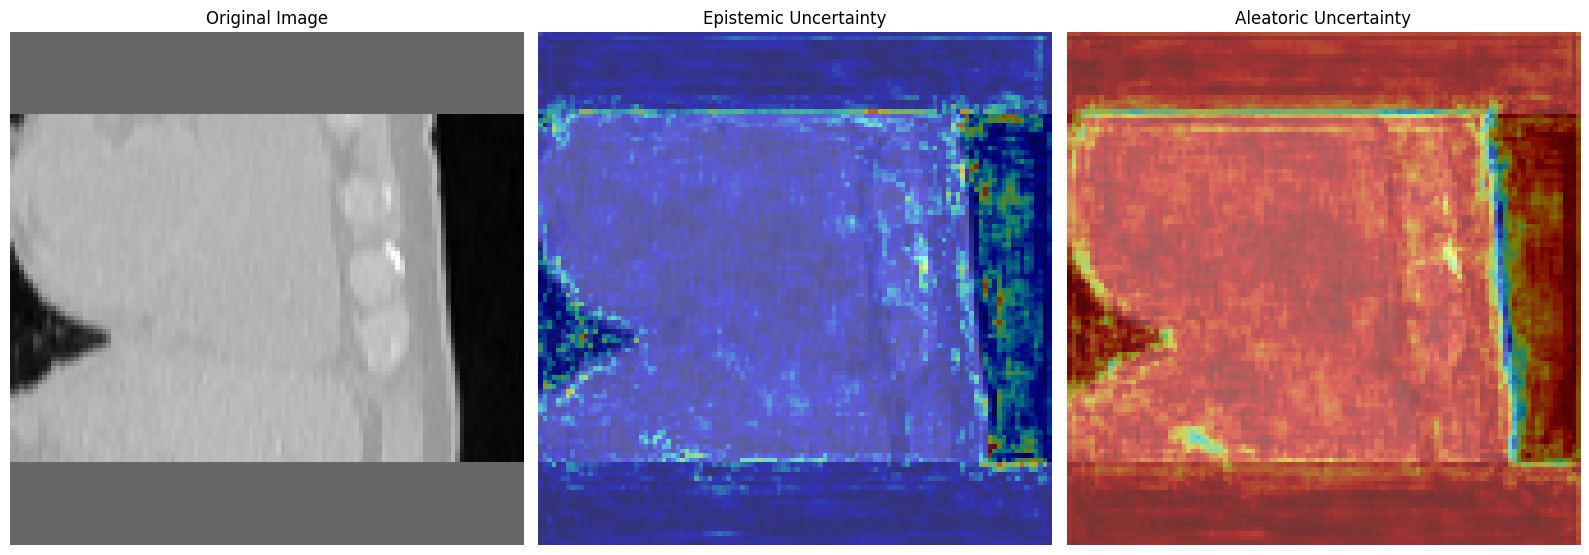

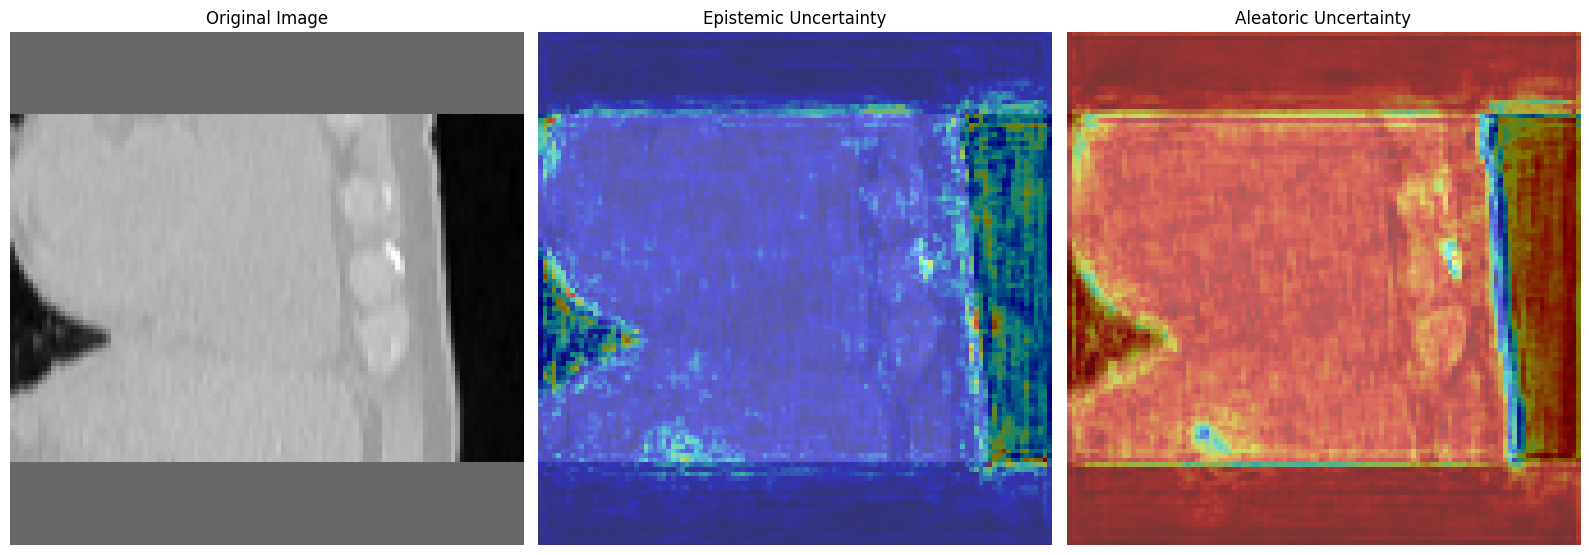

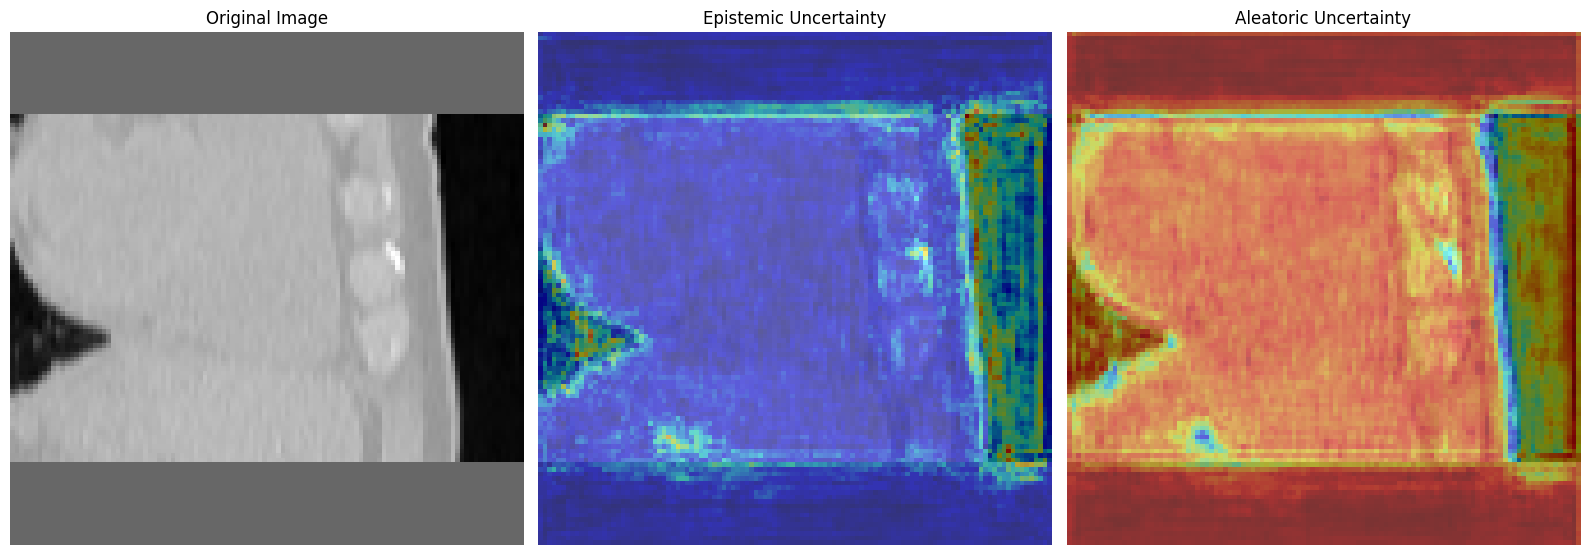

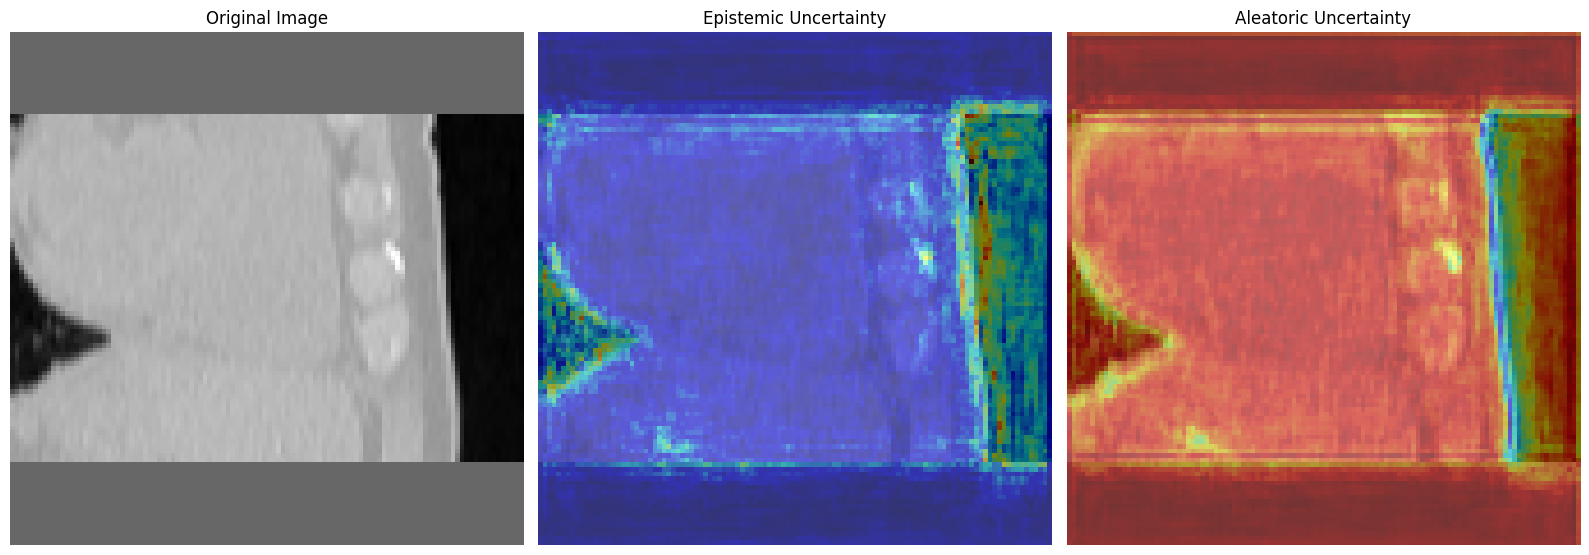

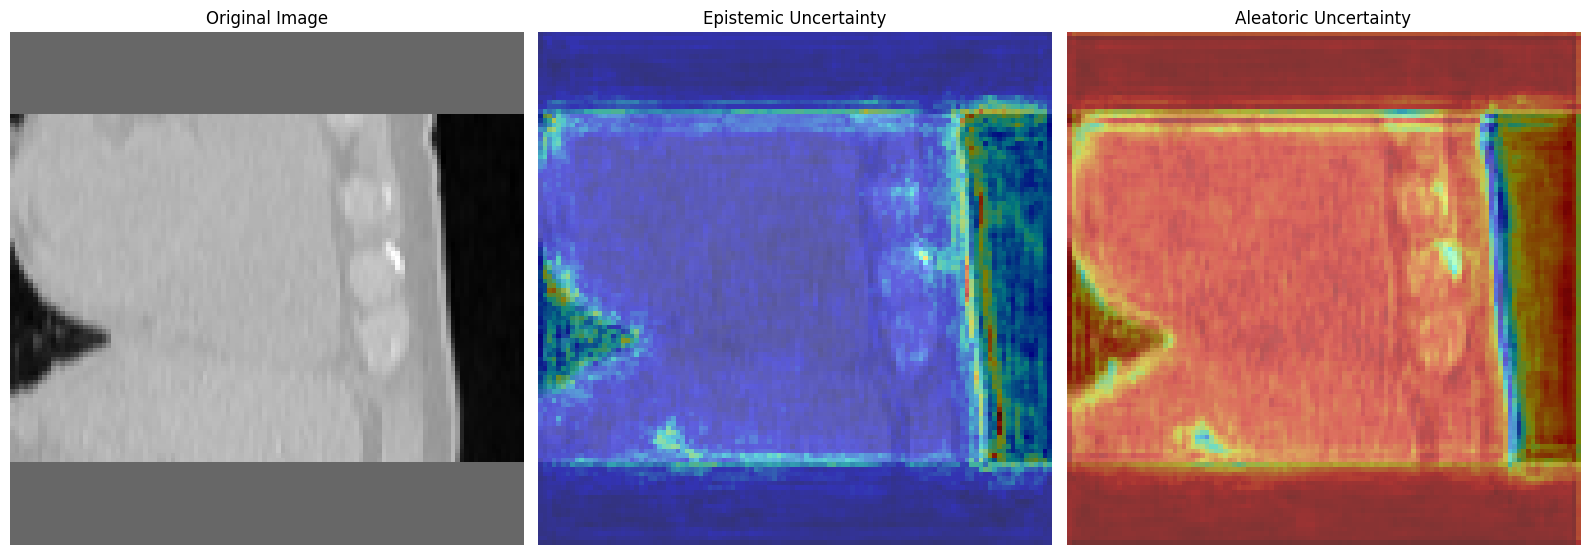

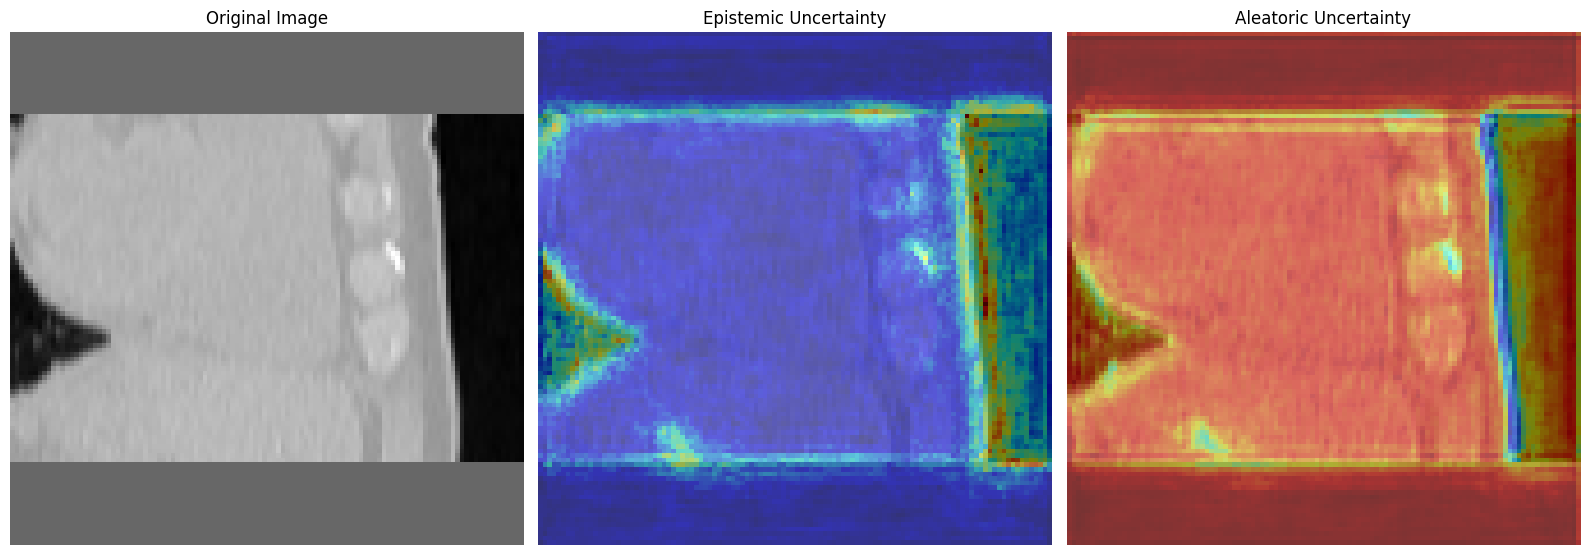

In [10]:
uncertainty_type1 = "Epistemic"
uncertainty_type2 = "Aleatoric"

for t in time:
    aleatoric_map = calculate_aleatoric_uncertainty(logit_dict[t])
    epistemic_map = calculate_epistemic_uncertainty(logit_dict[t])
    batch_idx = 2
    slice_idx =64 # 128의 중간정도 slice
    save_path="/mnt/HDD/yoonji/medmim/monte_carlo_{t}_1.png"
    visualize_uncertainty_on_img(uncertainty_type1=uncertainty_type1, uncertainty_map=epistemic_map,
                                uncertainty_type2=uncertainty_type2, uncertainty_map2=aleatoric_map,
                                original_img=inp, batch_idx=batch_idx, slice_idx=slice_idx, save_path=save_path)

### Aleatoric Uncertainty

## Mask overlap 확인

In [11]:
# 1. spark (random masking)
# 2. epistemic masking
# 3. aleatoric masking
def mask(B: int, device, generator=None): # masking randomly
        # h, w, d= self.fmap_h, self.fmap_w, self.fmap_d # shape of 7,7,8
        len_keep = round(7 * 7 * 8 * (1 - 0.6))
        h, w, d= 7,7,8
        idx = torch.rand(B, h * w * d, generator=generator).argsort(dim=1)
        idx = idx[:, :len_keep].to(device)  # (B, len_keep= HxWxDx0.4) # (4, 157)
        return torch.zeros(B, h * w * d,dtype=torch.bool, device=device).scatter_(dim=1, index=idx, value=True).view(B, 1, h, w, d)

def mask_intensity(B:int, device, uncertainty_map:torch.Tensor, intensity=True, masking_ratio=0.6): # intensity masking based on uncertainty
    
    out_tensor = F.avg_pool3d(uncertainty_map, kernel_size=(16,16,16), stride=(16,16,16))
    b,c,h,w,d = out_tensor.shape # out_tensor의 shape는 (4,1,7,7,8)로 예상

    tensor_flat = out_tensor.view(B, -1)
    if intensity is True:
        sorted_idx = tensor_flat.argsort(dim=1, descending=True)
        intensity = torch.linspace(0.0,1.0, steps = tensor_flat.shape[1], device=out_tensor.device)
        intensity_values = torch.zeros_like(tensor_flat)
        intensity_values.scatter_(dim=1, index=sorted_idx, src=intensity.unsqueeze(0).expand_as(sorted_idx))
        intensity_values.view(b,c,h,w,d)
        return intensity_values.view(b,c,h,w,d)
    else:
        topk = int(masking_ratio*tensor_flat.shape[1])
        _, topk_idx = torch.topk(tensor_flat, k=topk, dim=1, largest = True)
        mask = torch.ones(b, h*w*d, dtype=torch.bool, device=device)
        mask.scatter_(dim=1, index=topk_idx, src=torch.zeros_like(topk_idx, dtype=mask.dtype))
        return mask.view(b,1,h,w,d)

def mask_uncertainty(B: int, device, uncertainty_map1:torch.Tensor, uncertainty_map2:torch.Tensor): # masking based on uncertainty
        """
        Args:
            B: Batch size
            uncertainty_map: (B, 1, 112,112,128)

        Returns:
            mask: Boolean mask of shape (B, 1, fmap_h, fmap_w, fmap_d).
        """
        epistemic_feature_tensor = F.avg_pool3d(uncertainty_map1, kernel_size=(16,16,16), stride=(16,16,16))
        aleatoric_feature_tensor = F.avg_pool3d(uncertainty_map2, kernel_size=(16,16,16), stride=(16,16,16))

        b,c,h,w,d = aleatoric_feature_tensor.shape # out_tensor의 shape는 (4,1,7,7,8)로 예상

        ep_tensor_flat = epistemic_feature_tensor.view(B, -1)
        al_tensor_flat = aleatoric_feature_tensor.view(B,-1)

        topk =int(0.3*ep_tensor_flat.shape[1])
        _, ep_topk_idx = torch.topk(ep_tensor_flat, k=topk, dim=1, largest = True)
        _, al_topk_idx = torch.topk(al_tensor_flat, k=topk, dim=1, largest = True)
        union_idx = torch.unique(torch.cat([ep_topk_idx, al_topk_idx], dim=1), dim=1)

        mask = torch.ones(b, h*w*d, dtype=torch.bool, device=device)
        mask.scatter_(dim=1, index=union_idx, src=torch.zeros_like(union_idx, dtype=mask.dtype))

        return mask.view(b,1,h,w,d)





In [12]:
def mask_visualize(B:int, device, mask_type:str, inp_bchwd, uncertainty_map1, uncertainty_map2):
    downsample_ratio = 16
    inp_bchwd = inp_bchwd.to(device)
    uncertainty_map1 = uncertainty_map1.to(device)
    uncertainty_map2 = uncertainty_map2.to(device)
    
    
    if mask_type == "intensity":
        active_b1hwd_1 = mask_intensity(B, device, uncertainty_map1, intensity=True, masking_ratio = 0.6).repeat_interleave(downsample_ratio, 2).repeat_interleave(downsample_ratio,
                                                                                                 3).repeat_interleave(
            downsample_ratio, 4)  # (B, 1, H, W)
        active_b1hwd_2 = mask_intensity(B, device, uncertainty_map2, intensity=True, masking_ratio = 0.6).repeat_interleave(downsample_ratio, 2).repeat_interleave(downsample_ratio,
                                                                                                 3).repeat_interleave(
            downsample_ratio, 4)  # (B, 1, H, W)
        

        masked_bchwd1 = inp_bchwd*active_b1hwd_1
        masked_bchwd2 = inp_bchwd*active_b1hwd_2
        
        return masked_bchwd1, masked_bchwd2
    
    elif mask_type == "mask_uncertainty":
        active_mask = mask_uncertainty(B, device,uncertainty_map1, uncertainty_map2).repeat_interleave(downsample_ratio, 2).repeat_interleave(downsample_ratio,
                                                                                                 3).repeat_interleave(
            downsample_ratio, 4)  # (B, 1, H, W)
        masked_bchwd = inp_bchwd*active_mask
        
        return masked_bchwd
    
    elif mask_type == "random":
        active_mask = mask(B, device, None).repeat_interleave(downsample_ratio, 2).repeat_interleave(downsample_ratio,
                                                                                                 3).repeat_interleave(
            downsample_ratio, 4)  # (B, 1, H, W)
        masked_bchwd = inp_bchwd*active_mask
        
        return masked_bchwd

def visualize_masked_slice(masked_results, mask_type: str, slice_axis='depth', save_path=None):
    """
    masked_bchwd의 중간 slice를 시각화
    
    Args:
        masked_results: mask_visualize 함수의 반환값
        mask_type: str - "intensity", "mask_uncertainty", "random"
        slice_axis: str - 'depth'(z축), 'height'(y축), 'width'(x축) 중 선택
        save_path: str - 저장할 경로 (None이면 화면에 표시)
    """
    
    # tensor를 CPU로 이동하고 numpy로 변환하는 헬퍼 함수
    def tensor_to_numpy(tensor):
        if isinstance(tensor, torch.Tensor):
            return tensor.detach().cpu().numpy()
        return tensor
    
    # slice 축 설정
    axis_map = {'depth': -1, 'height': -2, 'width': -3}  # (B,C,H,W,D) 기준
    axis = axis_map.get(slice_axis, -1)
    
    if mask_type == "intensity":
        # 2개의 마스크 결과
        masked_bchwd1, masked_bchwd2 = masked_results
        
        # numpy로 변환
        mask1_np = tensor_to_numpy(masked_bchwd1)  # (1,1,h,w,d)
        mask2_np = tensor_to_numpy(masked_bchwd2)
        
        # 중간 slice 인덱스 계산
        mid_idx = mask1_np.shape[axis] // 2
        
        # slice 추출 (B=0, C=0 선택)
        if slice_axis == 'depth':
            slice1 = mask1_np[0, 0, :, :, mid_idx]  # (h, w)
            slice2 = mask2_np[0, 0, :, :, mid_idx]
        elif slice_axis == 'height':
            slice1 = mask1_np[0, 0, mid_idx, :, :]  # (w, d)
            slice2 = mask2_np[0, 0, mid_idx, :, :]
        else:  # width
            slice1 = mask1_np[0, 0, :, mid_idx, :]  # (h, d)
            slice2 = mask2_np[0, 0, :, mid_idx, :]
        
        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        im1 = axes[0].imshow(slice1, cmap='Blues', aspect='auto')
        axes[0].set_title(f'Intensity Mask 1 ({slice_axis} slice {mid_idx})')
        axes[0].axis('off')
        plt.colorbar(im1, ax=axes[0])
        
        im2 = axes[1].imshow(slice2, cmap='Blues', aspect='auto')
        axes[1].set_title(f'Intensity Mask 2 ({slice_axis} slice {mid_idx})')
        axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1])
        
    else:
        # 1개의 마스크 결과 (mask_uncertainty 또는 random)
        masked_bchwd = masked_results
        
        # numpy로 변환
        mask_np = tensor_to_numpy(masked_bchwd)
        
        # 중간 slice 인덱스 계산
        mid_idx = mask_np.shape[axis] // 2
        
        # slice 추출
        if slice_axis == 'depth':
            slice_data = mask_np[0, 0, :, :, mid_idx]  # (h, w)
        elif slice_axis == 'height':
            slice_data = mask_np[0, 0, mid_idx, :, :]  # (w, d)
        else:  # width
            slice_data = mask_np[0, 0, :, mid_idx, :]  # (h, d)
        
        # 시각화
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        
        im = ax.imshow(slice_data, cmap='Blues', aspect='auto')
        ax.set_title(f'{mask_type.title()} Mask ({slice_axis} slice {mid_idx})')
        ax.axis('off')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    
    # 저장 또는 표시
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved to: {save_path}")
    else:
        plt.show()
    
    plt.close()
    

In [13]:
B = 4
inp_bchwd = inp


# 각 마스크 타입별 시각화
#for mask_type in ["intensity", "mask_uncertainty"]:
for mask_type in ["mask_uncertainty"]:
    print(f"Visualizing {mask_type} mask...")
    
    # 마스크 생성
    masked_results = mask_visualize(B, device, mask_type, inp_bchwd, epistemic_map.unsqueeze(1), aleatoric_map)
    
    # 시각화
    visualize_masked_slice(
        masked_results, 
        mask_type, 
        slice_axis='depth',  # 'depth', 'height', 'width' 중 선택
        save_path=f"/mnt/HDD/yoonji/medmim/visualization/{mask_type}_mask_visualization.png"
    )

Visualizing mask_uncertainty mask...
Visualization saved to: /mnt/HDD/yoonji/medmim/visualization/mask_uncertainty_mask_visualization.png
